<a href="https://colab.research.google.com/github/ananthakrishnanm010/Case_Study_on_Preprocessing/blob/main/CNN_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from keras.utils import to_categorical, plot_model
from keras.models import Sequential
from keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.applications import VGG16

# Load dataset

In [2]:
import pickle
import numpy as np

# Path to your CIFAR-100 folder
data_path = "/content/drive/MyDrive/ICT_Data_Science/CIFAR"

# Load training data
with open(data_path + "/train", "rb") as f:
    train = pickle.load(f, encoding="bytes")

# Load test data
with open(data_path + "/test", "rb") as f:
    test = pickle.load(f, encoding="bytes")

# Extract images and labels
x_train = train[b"data"]
y_train = np.array(train[b"fine_labels"])

x_test = test[b"data"]
y_test = np.array(test[b"fine_labels"])

# Reshape images to (N, 32, 32, 3)
x_train = x_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
x_test = x_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(50000, 32, 32, 3)
(50000,)
(10000, 32, 32, 3)
(10000,)


In [3]:
X = np.concatenate((x_train, x_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

# Custom CNN

In [4]:
model = Sequential([
Conv2D(32,(3,3),padding='same',activation='relu',input_shape=(32,32,3)),
BatchNormalization(),
Conv2D(32,(3,3),activation='relu'),
MaxPooling2D(),
Dropout(0.25),

Conv2D(64,(3,3),padding='same',activation='relu'),
BatchNormalization(),
Conv2D(64,(3,3),activation='relu'),
MaxPooling2D(),
Dropout(0.30),

Conv2D(128,(3,3),padding='same',activation='relu'),
MaxPooling2D(),
Flatten(),
Dense(256,activation='relu'),
Dropout(0.5),
Dense(100,activation='softmax')
])

model.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 460,676 (1.76 MB)

 Trainable params: 460,484 (1.76 MB)

 Non-trainable params: 192 (768.00 B)

In [5]:
early = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

checkpoint = ModelCheckpoint(
'best_cnn.keras',
monitor='val_accuracy',
save_best_only=True)

history = model.fit(
x_train,
y_train,
validation_data=(x_test,y_test),
epochs=20,
batch_size=32,
callbacks=[early,checkpoint])


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.0727 - loss: 4.1076 - val_accuracy: 0.1585 - val_loss: 3.6082
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1528 - loss: 3.5550 - val_accuracy: 0.2007 - val_loss: 3.2972
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1995 - loss: 3.2914 - val_accuracy: 0.2222 - val_loss: 3.1824
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.2361 - loss: 3.0959 - val_accuracy: 0.2836 - val_loss: 2.8658
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2647 - loss: 2.9365 - val_accuracy: 0.2887 - val_loss: 2.8444
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2869 - loss: 2.8204 - val_accuracy: 0.3251 - val_loss: 2.6426
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3085 - loss: 2.7143 - val_accuracy: 0.2997 - val_loss: 2.7474
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3268 - loss: 2.6249 

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4486 - loss: 2.0637
CNN Accuracy: 0.44858333468437195


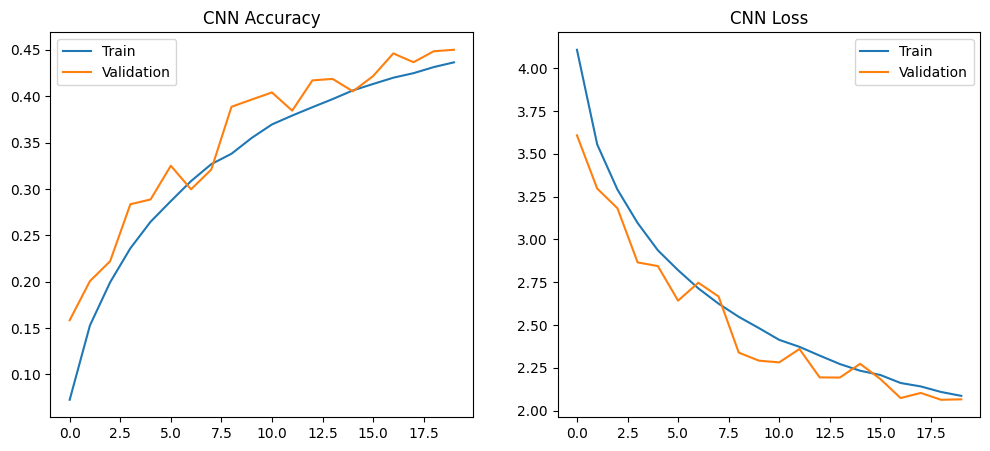

In [6]:
loss,acc=model.evaluate(x_test,y_test)
print("CNN Accuracy:",acc)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("CNN Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("CNN Loss")
plt.legend(["Train","Validation"])
plt.show()


# VGG Model

In [7]:
base_model=VGG16(weights='imagenet',
include_top=False,
input_shape=(32,32,3))

base_model.trainable=False

model_vgg=Sequential([
base_model,
Flatten(),
Dense(512,activation='relu'),
Dropout(0.5),
Dense(100,activation='softmax')
])

model_vgg.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

model_vgg.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,028,644 (57.33 MB)

 Trainable params: 313,956 (1.20 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [8]:
checkpoint_vgg=ModelCheckpoint(
'best_vgg16.keras',
monitor='val_accuracy',
save_best_only=True)

history_vgg=model_vgg.fit(
x_train,
y_train,
validation_data=(x_test,y_test),
epochs=20,
batch_size=32,
callbacks=[early,checkpoint_vgg])


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.1919 - loss: 3.4156 - val_accuracy: 0.2739 - val_loss: 2.9358
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.2697 - loss: 2.9542 - val_accuracy: 0.2991 - val_loss: 2.7867
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.2971 - loss: 2.8084 - val_accuracy: 0.3225 - val_loss: 2.7050
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.3162 - loss: 2.7143 - val_accuracy: 0.3307 - val_loss: 2.6572
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.3276 - loss: 2.6489 - val_accuracy: 0.3335 - val_loss: 2.6320


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2739 - loss: 2.9358
VGG16 Accuracy: 0.27391666173934937


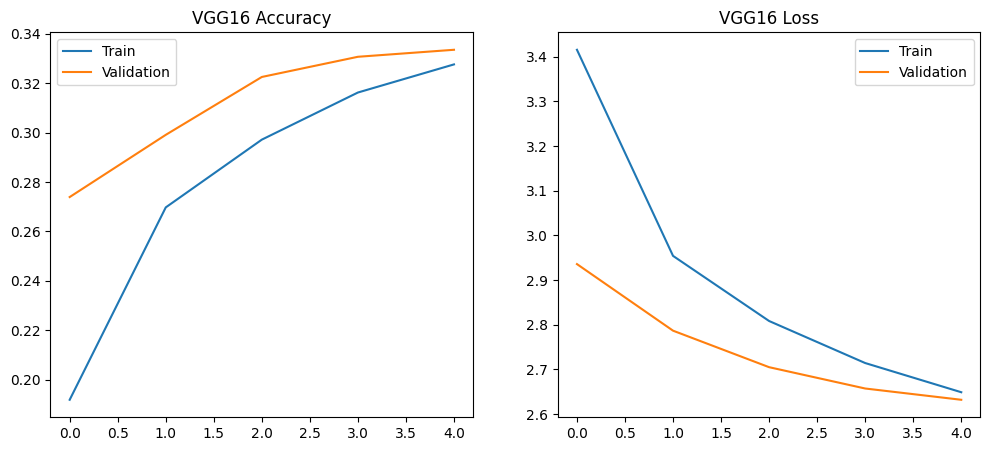

In [9]:
loss_vgg,acc_vgg=model_vgg.evaluate(x_test,y_test)

print("VGG16 Accuracy:",acc_vgg)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title("VGG16 Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])
plt.title("VGG16 Loss")
plt.legend(["Train","Validation"])
plt.show()


In [10]:
print("Final Comparison")
print("----------------")
print(f"CNN Accuracy    : {acc*100:.2f}%")
print(f"VGG16 Accuracy  : {acc_vgg*100:.2f}%")


Final Comparison
----------------
CNN Accuracy    : 44.86%
VGG16 Accuracy  : 27.39%
